In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# -------------------------------
# 0) Reproducibility
# -------------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)


In [3]:
# -------------------------------
# 1) Configuration
# -------------------------------
img_size = 64
batch_size = 16
num_classes = 5
input_shape = (img_size, img_size, 3)

train_path = "C:\\Users\\SATARUPA\\OneDrive\\Desktop\\Tiny ML\\Hydrophobicity Classes Photos part 2\\train"
val_path = "C:\\Users\\SATARUPA\\OneDrive\\Desktop\\Tiny ML\\Hydrophobicity Classes Photos part 2\\validation"

In [4]:
# -------------------------------
# 2) Data Generators
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=SEED,
)
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=SEED,
)


Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [5]:
# -------------------------------
# 3) Custom CNN (as in Teacher_model.ipynb)
# -------------------------------
def custom_cnn(x):
    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    #x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    #x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    #x = layers.Dropout(0.4)(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    #x = layers.Dropout(0.5)(x)

    x = layers.GlobalAveragePooling2D()(x)
    return x

In [6]:
# -------------------------------
# 4) Teacher model
# -------------------------------
def build_teacher(input_shape=(64, 64, 3), num_classes=5):
    inputs = Input(shape=input_shape)
    x = custom_cnn(inputs)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="teacher")

teacher = build_teacher(input_shape=input_shape, num_classes=num_classes)
teacher.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])  # [file:1]
teacher.summary()

Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0   

In [7]:
# -------------------------------
# 5) Callbacks (as in your Teacher_model.ipynb)
# -------------------------------
checkpoint = callbacks.ModelCheckpoint(
    "model_teacher_kd.keras", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1)
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1)


In [ ]:
# -------------------------------
# 6) Train TEACHER
# -------------------------------
teacher.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
print("\n[1/4] Training TEACHER...")
hist_teacher = teacher.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint, lr_reducer],
    verbose=2,
)


[1/4] Training TEACHER...
Epoch 1/20

Epoch 1: val_accuracy improved from -inf to 0.20000, saving model to model_teacher_kd.keras
125/125 - 49s - loss: 0.7951 - accuracy: 0.7005 - val_loss: 6.8392 - val_accuracy: 0.2000 - lr: 0.0010 - 49s/epoch - 391ms/step
Epoch 2/20

Epoch 2: val_accuracy did not improve from 0.20000
125/125 - 9s - loss: 0.5967 - accuracy: 0.7700 - val_loss: 13.3191 - val_accuracy: 0.2000 - lr: 0.0010 - 9s/epoch - 74ms/step
Epoch 3/20

Epoch 3: val_accuracy improved from 0.20000 to 0.20600, saving model to model_teacher_kd.keras
125/125 - 9s - loss: 0.4243 - accuracy: 0.8290 - val_loss: 6.1514 - val_accuracy: 0.2060 - lr: 0.0010 - 9s/epoch - 74ms/step
Epoch 4/20

Epoch 4: val_accuracy improved from 0.20600 to 0.54800, saving model to model_teacher_kd.keras
125/125 - 9s - loss: 0.4241 - accuracy: 0.8485 - val_loss: 1.2897 - val_accuracy: 0.5480 - lr: 0.0010 - 9s/epoch - 74ms/step
Epoch 5/20

Epoch 5: val_accuracy improved from 0.54800 to 0.78800, saving model to mode

In [13]:
# Save teacher model
teacher.save("C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/parato_teacher_model_part 2.keras")


In [20]:
# -------------------------------
# 3) Flexible CNN Builder
# -------------------------------
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout

def create_kws_model(conv_layers, filters, kernel_size, fc_layers, use_bn, use_dropout,
                     input_shape=(64, 64, 3), num_classes=7):
    model = Sequential()
    
    # First conv block
    model.add(Conv2D(filters, kernel_size=kernel_size, activation='relu',
                     input_shape=input_shape, padding='same'))
    if use_bn:
        model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    
    # Remaining conv blocks
    for _ in range(conv_layers - 1):
        model.add(Conv2D(filters, kernel_size=kernel_size, activation='relu', padding='same'))
        if use_bn:
            model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    
    model.add(Flatten())
    
    # Fully connected head
    fc_map = {1: [64], 2: [128, 64], 3: [256, 128, 64], 4: [512, 256, 128, 64]}
    neurons_list = fc_map.get(fc_layers, [64])
    for n in neurons_list:
        model.add(Dense(n, activation='relu'))
        if use_dropout:
            model.add(Dropout(0.5))
    
    model.add(Dense(num_classes, activation='softmax'))
    return model


In [21]:
# -------------------------------
# 4) Load pre-trained TEACHER (minimal)
# -------------------------------
from tensorflow.keras.models import load_model

teacher = load_model("C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/parato_teacher_model_part 2.keras")
teacher.trainable = False  # optional: freeze during KD
teacher.summary()

Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0   

In [22]:
# -------------------------------
# 5) Create STUDENT models (using flexible CNN)
# -------------------------------

# Choose any hyperparameters you like for the students
baseline_params = {
    "conv_layers": 4,
    "filters": 128,
    "kernel_size": 3,
    "fc_layers": 1,
    "use_bn": True,
    "use_dropout": False,
}

student_baseline = create_kws_model(**baseline_params,
                                    input_shape=input_shape,
                                    num_classes=num_classes)

student_for_kd = create_kws_model(**baseline_params,
                                  input_shape=input_shape,
                                  num_classes=num_classes)

student_baseline.summary()
student_for_kd.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 64, 64, 128)       3584      
                                                                 
 batch_normalization_24 (Bat  (None, 64, 64, 128)      512       
 chNormalization)                                                
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 32, 32, 128)      0         
 g2D)                                                            
                                                                 
 conv2d_25 (Conv2D)          (None, 32, 32, 128)       147584    
                                                                 
 batch_normalization_25 (Bat  (None, 32, 32, 128)      512       
 chNormalization)                                                
                                                      

In [23]:
# -------------------------------
# 6) Train BASELINE STUDENT (no KD)
# -------------------------------
student_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print("\n[2/4] Training STUDENT (baseline, no KD)...")
hist_baseline = student_baseline.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, lr_reducer],
    verbose=2,
)



[2/4] Training STUDENT (baseline, no KD)...
Epoch 1/20
125/125 - 18s - loss: 0.9250 - accuracy: 0.6710 - val_loss: 2.4604 - val_accuracy: 0.2880 - lr: 0.0010 - 18s/epoch - 147ms/step
Epoch 2/20
125/125 - 8s - loss: 0.5135 - accuracy: 0.8070 - val_loss: 5.1257 - val_accuracy: 0.2140 - lr: 0.0010 - 8s/epoch - 60ms/step
Epoch 3/20
125/125 - 7s - loss: 0.4985 - accuracy: 0.8015 - val_loss: 2.7733 - val_accuracy: 0.4020 - lr: 0.0010 - 7s/epoch - 60ms/step
Epoch 4/20

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 - 7s - loss: 0.4425 - accuracy: 0.8490 - val_loss: 2.6537 - val_accuracy: 0.3060 - lr: 0.0010 - 7s/epoch - 59ms/step
Epoch 5/20
125/125 - 7s - loss: 0.3084 - accuracy: 0.8765 - val_loss: 1.0150 - val_accuracy: 0.6920 - lr: 5.0000e-04 - 7s/epoch - 59ms/step
Epoch 6/20
125/125 - 7s - loss: 0.2337 - accuracy: 0.9100 - val_loss: 0.7682 - val_accuracy: 0.7780 - lr: 5.0000e-04 - 7s/epoch - 58ms/step
Epoch 7/20
125/125 - 7s - loss: 0.2457 - accuracy: 

In [24]:
student_baseline.save("C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/student_baseline_model.keras")


In [25]:
# -------------------------------
# 8) KD STUDENT via Distiller (probability-based temperature, categorical)
# -------------------------------
def temp_scale_probs(p, T, eps=1e-8):
    # p: (batch, num_classes) probabilities
    p = tf.clip_by_value(p, eps, 1.0)
    pT = tf.pow(p, 1.0 / T)
    pT = pT / tf.reduce_sum(pT, axis=-1, keepdims=True)
    return pT

class Distiller(Model):
    def __init__(self, student, teacher, T=2.0, alpha=0.7):
        super().__init__(name="distiller_softmax")
        self.student = student
        self.teacher = teacher
        self.teacher.trainable = False
        self.T = float(T)
        self.alpha = float(alpha)
        self.ce = keras.losses.CategoricalCrossentropy()
        self.kld = keras.losses.KLDivergence()
        self.acc = keras.metrics.CategoricalAccuracy(name="acc")
        self.hard_tracker = keras.metrics.Mean(name="hard_loss")
        self.soft_tracker = keras.metrics.Mean(name="soft_loss")
        self.kd_tracker = keras.metrics.Mean(name="kd_loss")

    @property
    def metrics(self):
        return [self.acc, self.hard_tracker, self.soft_tracker, self.kd_tracker]

    def train_step(self, data):
        x, y = data

        t_probs = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            s_probs = self.student(x, training=True)
            hard = self.ce(y, s_probs)
            t_T = temp_scale_probs(t_probs, self.T)
            s_T = temp_scale_probs(s_probs, self.T)
            soft = self.kld(t_T, s_T)
            kd_total = self.alpha * hard + (1.0 - self.alpha) * (self.T ** 2) * soft
        grads = tape.gradient(kd_total, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.acc.update_state(y, s_probs)
        self.hard_tracker.update_state(hard)
        self.soft_tracker.update_state(soft)
        self.kd_tracker.update_state(kd_total)
        return {"loss": kd_total, "acc": self.acc.result(),
                "hard_loss": self.hard_tracker.result(),
                "soft_loss": self.soft_tracker.result(),
                "kd_loss": self.kd_tracker.result()}

    def test_step(self, data):
        x, y = data
        s_probs = self.student(x, training=False)
        loss = self.ce(y, s_probs)
        self.acc.update_state(y, s_probs)
        return {"loss": loss, "acc": self.acc.result()}

In [26]:
# -------------------------------
# KD STUDENT Training (single run)
# -------------------------------
# KD knobs (CHANGE THESE)
T = 6.0
alpha = 0.5

# Create KD student (same params as baseline)
student_for_kd = create_kws_model(**baseline_params,
                                  input_shape=input_shape,
                                  num_classes=num_classes)

# Distiller
distiller = Distiller(student=student_for_kd, teacher=teacher, T=T, alpha=alpha)
distiller.compile(optimizer=keras.optimizers.Adam(1e-3))

print("\n[3/4] Training STUDENT with KD (softmax models)...")
hist_kd = distiller.fit(
    train_data,  # Your ImageDataGenerator
    validation_data=val_data,  # Your ImageDataGenerator
    epochs=30,
    callbacks=[early_stop, lr_reducer],  # Your callbacks
    verbose=2
)





[3/4] Training STUDENT with KD (softmax models)...
Epoch 1/30
125/125 - 11s - loss: 2.6913 - acc: 0.6980 - hard_loss: 1.0056 - soft_loss: 0.1314 - kd_loss: 2.8677 - val_loss: 0.0613 - val_acc: 0.2000 - lr: 0.0010 - 11s/epoch - 90ms/step
Epoch 2/30
125/125 - 8s - loss: 1.9857 - acc: 0.8035 - hard_loss: 0.6341 - soft_loss: 0.0792 - kd_loss: 1.7424 - val_loss: 5.8977e-05 - val_acc: 0.2000 - lr: 0.0010 - 8s/epoch - 65ms/step
Epoch 3/30
125/125 - 8s - loss: 1.1512 - acc: 0.8395 - hard_loss: 0.4557 - soft_loss: 0.0559 - kd_loss: 1.2347 - val_loss: 0.0083 - val_acc: 0.3680 - lr: 0.0010 - 8s/epoch - 61ms/step
Epoch 4/30
125/125 - 8s - loss: 1.1211 - acc: 0.8650 - hard_loss: 0.3846 - soft_loss: 0.0515 - kd_loss: 1.1202 - val_loss: 1.0937e-05 - val_acc: 0.3980 - lr: 0.0010 - 8s/epoch - 62ms/step
Epoch 5/30

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 - 8s - loss: 0.6280 - acc: 0.8820 - hard_loss: 0.3609 - soft_loss: 0.0487 - kd_loss: 1.0569 - val_loss: 0.

In [27]:
# Save KD student
student_for_kd.save("C:/Users/SATARUPA/OneDrive/Desktop/Tiny ML/parato_student_kd_2_part_2.keras")
print("KD student saved!")

KD student saved!


Index(['Student', 'Model size(mb)', 'Accuracy in parato range',
       'boost up accuracy after CL-KD(Proposed)'],
      dtype='object')


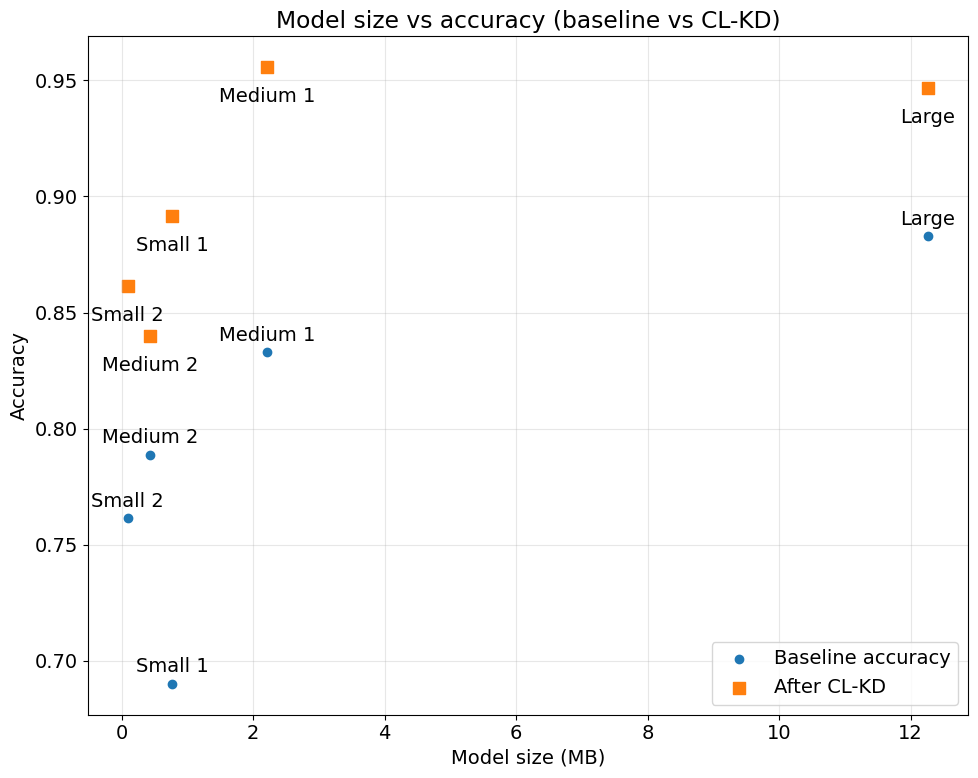

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global font size
plt.rcParams.update({"font.size": 14})


file_path = "parato analysis.xlsx"

# Header row is the second row in the sheet
df = pd.read_excel(file_path, header=1)

# Strip spaces from column names
df.columns = df.columns.str.strip()

print(df.columns)  # debug

name_col = "Student"
size_col = "Model size(mb)"
base_acc_col = "Accuracy in parato range"
boost_acc_col = "boost up accuracy after CL-KD(Proposed)"

# Sort by model size
df_sorted = df.sort_values(by=size_col)

plt.figure(figsize=(10, 8))

# Baseline accuracy - only dots
plt.scatter(
    df_sorted[size_col],
    df_sorted[base_acc_col],
    marker="o",
    color="tab:blue",
    label="Baseline accuracy"
)

# Accuracy after CL-KD - only dots, bigger + different color
plt.scatter(
    df_sorted[size_col],
    df_sorted[boost_acc_col],
    marker="s",
    s=80,                # size of markers
    color="tab:orange",
    label="After CL-KD"
)

# Annotate each point with model name
for _, row in df_sorted.iterrows():
    x = row[size_col]
    y_base = row[base_acc_col]
    y_boost = row[boost_acc_col]
    name = row[name_col]
    plt.text(x, y_base + 0.005, name, ha="center", fontsize=14)
    plt.text(x, y_boost - 0.015, name, ha="center", fontsize=14)

plt.xlabel("Model size (MB)")
plt.ylabel("Accuracy")
plt.title("Model size vs accuracy (baseline vs CL-KD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
